## Debug : Répétitions d'inférence MC sur une image unique
Reproduit la logique du benchmark sur **une seule image** :
répète l'évaluation complète (T passes MC) de 1 à 100 fois par paliers de 10,
et affiche mean ± std de l'accuracy au fil des répétitions.

In [4]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torchvision.transforms import v2
from medmnist import PathMNIST, INFO
from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn

print('Imports OK')

Imports OK


### Config

In [5]:
CHECKPOINT_PATH  = "models/Mats/BayMoped_full_run1.pth"   # ← adapte
BASE_EFFNET_PATH = "models/effNet.pth"
NUM_MONTE_CARLO  = 100    # passes MC par évaluation (T)
N_TOTAL_CALLS    = 100    # nombre total de répétitions
CHECKPOINT_EVERY = 10     # paliers
IMAGE_INDEX      = None   # None = aléatoire, ou entier pour fixer
SEED             = 42

device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available() else 'cpu'
)
print(f'Device : {device}')

Device : cuda


### Dataset & image

Images tirées : [np.int64(1470), np.int64(7049), np.int64(5035), np.int64(583), np.int64(295), np.int64(1398), np.int64(4962), np.int64(6948), np.int64(3643), np.int64(1155), np.int64(2128), np.int64(3065), np.int64(97), np.int64(2682), np.int64(4112), np.int64(1033), np.int64(6811), np.int64(923), np.int64(2513), np.int64(498)]


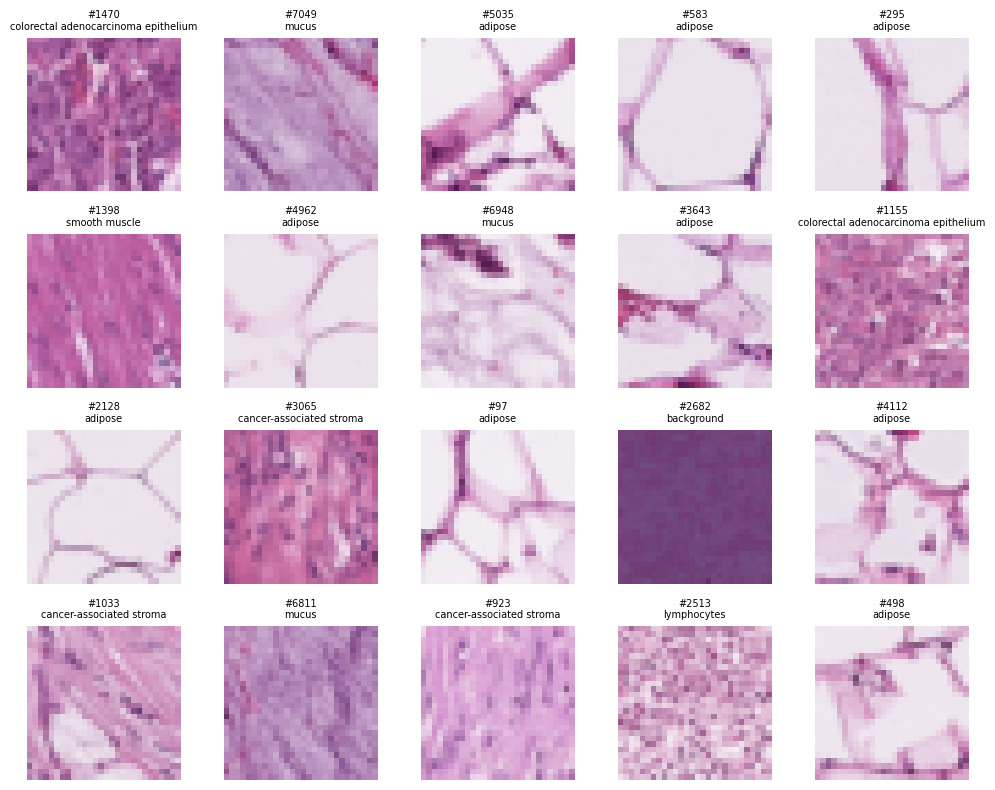

In [20]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

testset = PathMNIST(split='test', download=True, size=28, transform=transform)
info    = INFO['pathmnist']
CLASSES = list(info['label'].values())

N_IMAGES = 20
rng      = np.random.default_rng()
indices  = rng.integers(0, len(testset), size=N_IMAGES)

images     = []
true_labels = []
for idx in indices:
    img_t, lbl = testset[idx]
    images.append(img_t)
    true_labels.append(int(lbl.squeeze()))

print(f'Images tirées : {list(indices)}')

# Affichage grille 4x5
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    img_display = images[i].permute(1, 2, 0).numpy()
    img_display = (img_display * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img_display)
    ax.set_title(f'#{indices[i]}\n{CLASSES[true_labels[i]]}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Chargement du modèle full_moped

In [14]:
BNN_PRIOR_MOPED = {
    'prior_mu': 0.0, 'prior_sigma': 1.0,
    'posterior_mu_init': 0.0, 'posterior_rho_init': -3.0,
    'type': 'Reparameterization',
    'moped_enable': True, 'moped_delta': 0.5,
}

net = torchvision.models.efficientnet_b0(progress=False)
net.classifier[1] = nn.Linear(1280, 9)
base = torch.load(BASE_EFFNET_PATH, map_location=device)
net.load_state_dict(base['model_state_dict'])
dnn_to_bnn(net, BNN_PRIOR_MOPED)
net.to(device)
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
net.load_state_dict(ckpt['model_state_dict'])
net.eval()

print('Modèle chargé ✓')

Modèle chargé ✓


### Fonction d'évaluation sur une image unique

In [15]:
def evaluate_single_image(net, img_tensor, true_label, num_monte_carlo, device):
    """
    Réplique de evaluate_full() mais sur une image unique.
    Retourne (accuracy: 0.0 ou 1.0, classe prédite).
    """
    x = img_tensor.unsqueeze(0).to(device)   # (1, 3, 28, 28)
    output_mc = []
    with torch.no_grad():
        for _ in range(num_monte_carlo):
            logits = net(x)
            probs  = torch.softmax(logits, dim=-1)
            output_mc.append(probs)
    output    = torch.stack(output_mc)        # (T, 1, 9)
    pred_mean = output.mean(dim=0)            # (1, 9)
    y_pred    = int(torch.argmax(pred_mean, dim=1).item())
    return float(y_pred == true_label), y_pred

### Boucle de répétitions

In [ ]:
checkpoints_all   = []   # une liste de checkpoints par image
accuracies_window = []
preds_window      = []

for img_i, (img_tensor, true_label) in enumerate(zip(images, true_labels)):
    checkpoints       = []
    accuracies_window = []
    preds_window      = []

    for call_i in range(N_TOTAL_CALLS):
        acc, y_pred = evaluate_single_image(
            net, img_tensor, true_label, NUM_MONTE_CARLO, device
        )
        accuracies_window.append(acc)
        preds_window.append(y_pred)

        if (call_i + 1) % CHECKPOINT_EVERY == 0:
            mean_acc = float(np.mean(accuracies_window))
            std_acc  = float(np.std(accuracies_window))
            checkpoints.append({
                'call_index':   call_i + 1,
                'mean_acc':     mean_acc,
                'std_acc':      std_acc,
                'preds_window': preds_window.copy(),
            })
            print(f'  [img {img_i:2d} #{indices[img_i]}] call {call_i+1:3d}/100 | '
                  f'mean={100*mean_acc:.1f}% ± {100*std_acc:.1f}% | preds={preds_window}')
            accuracies_window = []
            preds_window      = []

    checkpoints_all.append({
        'img_idx':    int(indices[img_i]),
        'true_label': true_label,
        'checkpoints': checkpoints,
    })

print('\nTerminé ✓')

  call  10/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  20/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  30/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  40/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  50/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  60/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  70/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  80/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call  90/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  call 100/100 | mean=100.0% ± 0.0% | preds=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Terminé ✓


### Visualisation

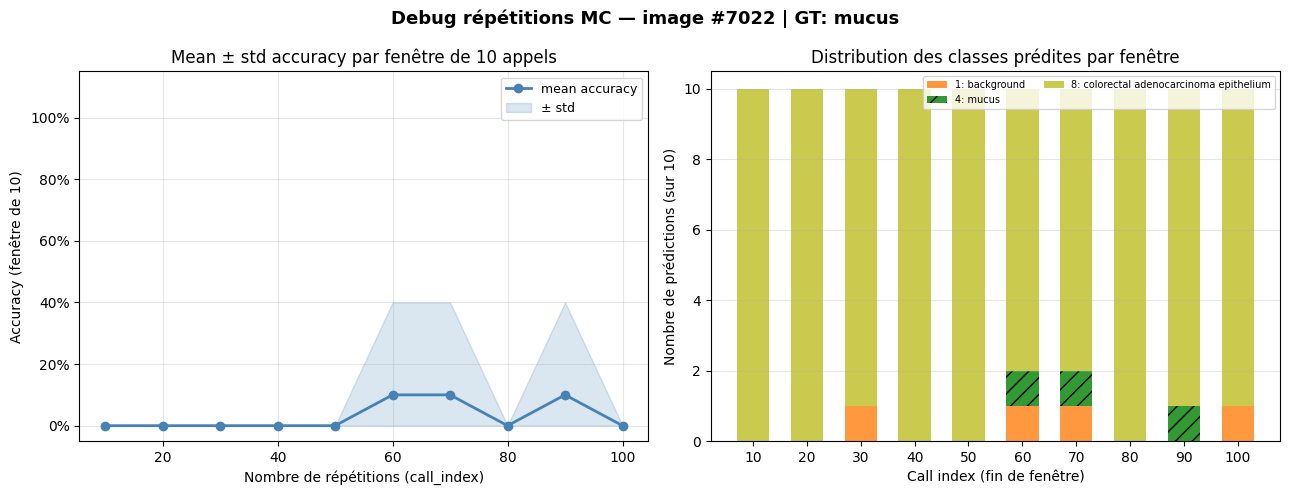

Figure sauvegardée : debug_repetitions.png


In [11]:
call_indices = [cp['call_index'] for cp in checkpoints]
mean_accs    = np.array([cp['mean_acc'] for cp in checkpoints])
std_accs     = np.array([cp['std_acc']  for cp in checkpoints])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Debug répétitions MC — image #{idx} | GT: {CLASSES[true_label]}',
    fontsize=13, fontweight='bold'
)

# ── 1. Mean ± std accuracy par fenêtre ──────────────────────────────
ax = axes[0]
ax.plot(call_indices, mean_accs, 'o-', color='steelblue', lw=2, ms=6, label='mean accuracy')
ax.fill_between(call_indices,
                np.clip(mean_accs - std_accs, 0, 1),
                np.clip(mean_accs + std_accs, 0, 1),
                alpha=0.2, color='steelblue', label='± std')
ax.set_xlabel('Nombre de répétitions (call_index)')
ax.set_ylabel('Accuracy (fenêtre de 10)')
ax.set_title('Mean ± std accuracy par fenêtre de 10 appels')
ax.set_ylim(-0.05, 1.15)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 2. Distribution des prédictions par fenêtre ─────────────────────
ax = axes[1]
bottom   = np.zeros(len(checkpoints))
x_pos    = np.arange(len(checkpoints))
cmap     = plt.get_cmap('tab10')
class_counts = {c: [cp['preds_window'].count(c) for cp in checkpoints] for c in range(len(CLASSES))}

for c_idx in range(len(CLASSES)):
    vals = np.array(class_counts[c_idx])
    if vals.sum() == 0:
        continue
    color = 'green' if c_idx == true_label else cmap(c_idx / len(CLASSES))
    hatch = '//' if c_idx == true_label else None
    ax.bar(x_pos, vals, bottom=bottom, label=f'{c_idx}: {CLASSES[c_idx]}',
           color=color, hatch=hatch, alpha=0.8, width=0.6)
    bottom += vals

ax.set_xticks(x_pos)
ax.set_xticklabels(call_indices)
ax.set_xlabel('Call index (fin de fenêtre)')
ax.set_ylabel('Nombre de prédictions (sur 10)')
ax.set_title('Distribution des classes prédites par fenêtre')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('debug_repetitions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : debug_repetitions.png')

### Résultats

In [12]:
all_preds_flat = [p for cp in checkpoints for p in cp['preds_window']]

print('=== Résumé diagnostic ===')
print(f'  Image #{idx}  |  GT: {true_label} ({CLASSES[true_label]})')
print()
print('  Mean ± std accuracy par fenêtre de 10 appels :')
for cp in checkpoints:
    bar = '█' * int(cp['mean_acc'] * 20)
    print(f"    calls {cp['call_index']-9:3d}–{cp['call_index']:3d} : "
          f"{100*cp['mean_acc']:5.1f}% ± {100*cp['std_acc']:.1f}%  {bar}")
print()
print(f'  Variance globale des mean_acc : {np.var(mean_accs):.6f}')
print(f'  → Si ≈ 0 : accuracy identique à chaque répétition (suspect !)')
print()
unique, counts = np.unique(all_preds_flat, return_counts=True)
print('  Distribution globale des 100 prédictions :')
for cls_id, cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    bar = '█' * int(cnt / N_TOTAL_CALLS * 40)
    marker = ' ← GT' if cls_id == true_label else ''
    print(f'    Classe {cls_id} ({CLASSES[cls_id]:20s}) : {cnt:3d}/100 {bar}{marker}')

=== Résumé diagnostic ===
  Image #7022  |  GT: 4 (mucus)

  Mean ± std accuracy par fenêtre de 10 appels :
    calls   1– 10 :   0.0% ± 0.0%  
    calls  11– 20 :   0.0% ± 0.0%  
    calls  21– 30 :   0.0% ± 0.0%  
    calls  31– 40 :   0.0% ± 0.0%  
    calls  41– 50 :   0.0% ± 0.0%  
    calls  51– 60 :  10.0% ± 30.0%  ██
    calls  61– 70 :  10.0% ± 30.0%  ██
    calls  71– 80 :   0.0% ± 0.0%  
    calls  81– 90 :  10.0% ± 30.0%  ██
    calls  91–100 :   0.0% ± 0.0%  

  Variance globale des mean_acc : 0.002100
  → Si ≈ 0 : accuracy identique à chaque répétition (suspect !)

  Distribution globale des 100 prédictions :
    Classe 8 (colorectal adenocarcinoma epithelium) :  93/100 █████████████████████████████████████
    Classe 1 (background          ) :   4/100 █
    Classe 4 (mucus               ) :   3/100 █ ← GT
